In [ ]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ 

Looking in indexes: https://mirror-pypi.runflare.com/simple/
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 2.9 MB/s eta 0:00:35
   ---------------------------------------- 1.0/100.2 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 1.3/100.2 MB 2.1 MB/s eta 0:00:48
    --------------------------------------- 1.6/100.2 MB 1.8 MB/s eta 0:00:55
    --------------------------------------- 1.6/100.2 MB 1.8 MB/s eta 0:00:55
    --------------------------------------- 1.8/100.2 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 1.8/100.2 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 2.1/100.2 MB 1.2 MB/s eta 0:01:19
    --------------------------------------- 2.4/100.2 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 2.4/100.2 MB 1.2 MB/s eta 0:01:24
   - ------------

In [12]:
import pandas as pd
import numpy as np
import imblearn
import seaborn as sns

In [13]:
df = pd.read_csv(r'data\train.csv')
df.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [14]:
df.columns

Index(['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03',
       'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin',
       'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin',
       'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15',
       'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01',
       'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat',
       'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
       'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat',
       'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14',
       'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
       'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09',
       'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14',
       'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin',
       'ps_calc_19_bin', 'ps_calc_20_bin'],


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

<Axes: xlabel='target', ylabel='count'>

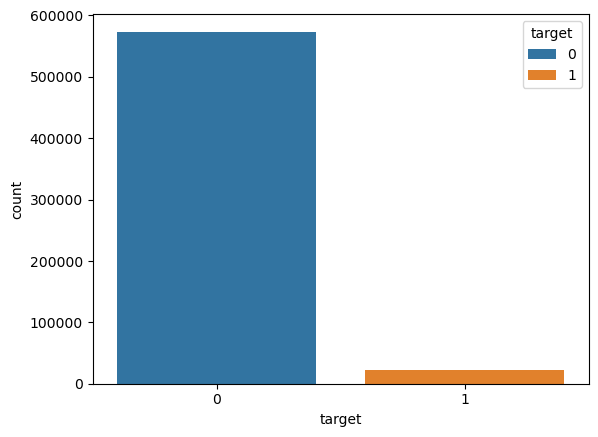

In [19]:
sns.countplot(data=df, x='target', hue='target')

In [22]:
df.groupby('target')['id'].count() / len(df)

target
0    0.963552
1    0.036448
Name: id, dtype: float64

In [24]:
from catboost import CatBoostClassifier

In [25]:
X = df.iloc[:, 2:]
X.head()

,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,2,2,5,1,0,0,1,0,0,0,...,9,1,5,8,0,1,1,0,0,1
1,1,1,7,0,0,0,0,1,0,0,...,3,1,1,9,0,1,1,0,1,0
2,5,4,9,1,0,0,0,1,0,0,...,4,2,7,7,0,1,1,0,1,0
3,0,1,2,0,0,1,0,0,0,0,...,2,2,4,9,0,0,0,0,0,0
4,0,2,0,1,0,1,0,0,0,0,...,3,1,1,3,0,0,0,1,1,0


In [26]:
y = df['target']

In [29]:
cat_col = [i for i in range(len(X.columns)) if 'cat' in X.columns[i]]
cat_col

[1, 3, 4, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [31]:
model = CatBoostClassifier(iterations=100, learning_rate=0.1,
                           depth=6, eval_metric='Accuracy', verbose=10, task_type='GPU')

model.fit(X_train, y_train, cat_col, eval_set=(X_test, y_test))

0:	learn: 0.9637216	test: 0.9630451	best: 0.9630451 (0)	total: 23.4ms	remaining: 2.32s
10:	learn: 0.9637216	test: 0.9630451	best: 0.9630451 (0)	total: 182ms	remaining: 1.48s
20:	learn: 0.9637216	test: 0.9630451	best: 0.9630451 (0)	total: 334ms	remaining: 1.26s
30:	learn: 0.9637261	test: 0.9630451	best: 0.9630451 (0)	total: 478ms	remaining: 1.06s
40:	learn: 0.9637440	test: 0.9630451	best: 0.9630451 (0)	total: 624ms	remaining: 898ms
50:	learn: 0.9637485	test: 0.9630518	best: 0.9630518 (43)	total: 768ms	remaining: 737ms
60:	learn: 0.9637597	test: 0.9630518	best: 0.9630518 (43)	total: 914ms	remaining: 584ms
70:	learn: 0.9637687	test: 0.9630518	best: 0.9630518 (43)	total: 1.07s	remaining: 437ms
80:	learn: 0.9637731	test: 0.9630518	best: 0.9630518 (43)	total: 1.24s	remaining: 292ms
90:	learn: 0.9637754	test: 0.9630518	best: 0.9630518 (43)	total: 1.39s	remaining: 137ms
99:	learn: 0.9637799	test: 0.9630451	best: 0.9630518 (43)	total: 1.52s	remaining: 0us
bestTest = 0.9630518202
bestIteration =

CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=100, learning_rate=0.1, task_type='GPU', verbose=10)

In [38]:
from sklearn.metrics import confusion_matrix, classification_report

In [36]:
y_pred = model.predict(X_test)
con_matrix = confusion_matrix(y_pred=y_pred, y_true=y_test)
con_matrix

array([[143304,      0],
       [  5498,      1]])

In [40]:
cls_rep = classification_report(y_pred=y_pred, y_true=y_test)
print(cls_rep)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98    143304
           1       1.00      0.00      0.00      5499

    accuracy                           0.96    148803
   macro avg       0.98      0.50      0.49    148803
weighted avg       0.96      0.96      0.94    148803



In [41]:
from imblearn.under_sampling import RandomUnderSampler

In [42]:
RUS = RandomUnderSampler()
X_rus, y_rus = RUS.fit_resample(X_train, y_train)

In [44]:
np.shape(X_rus)

(32390, 57)

In [45]:
np.unique(y_rus, return_counts=True)

(array([0, 1]), array([16195, 16195]))

In [46]:
model = CatBoostClassifier(iterations=300, learning_rate=0.1,
                           depth=6, eval_metric='Accuracy', verbose=10, task_type='GPU')

model.fit(X_rus, y_rus, cat_col, eval_set=(X_test, y_test))

0:	learn: 0.5824946	test: 0.6485891	best: 0.6485891 (0)	total: 40ms	remaining: 12s
10:	learn: 0.5980550	test: 0.6150615	best: 0.6485891 (0)	total: 436ms	remaining: 11.4s
20:	learn: 0.6045693	test: 0.6113654	best: 0.6485891 (0)	total: 818ms	remaining: 10.9s
30:	learn: 0.6071936	test: 0.6157940	best: 0.6485891 (0)	total: 1.2s	remaining: 10.4s
40:	learn: 0.6120716	test: 0.6173935	best: 0.6485891 (0)	total: 1.57s	remaining: 9.95s
50:	learn: 0.6145724	test: 0.6164661	best: 0.6485891 (0)	total: 1.95s	remaining: 9.51s
60:	learn: 0.6167644	test: 0.6170843	best: 0.6485891 (0)	total: 2.32s	remaining: 9.1s
70:	learn: 0.6191726	test: 0.6173061	best: 0.6485891 (0)	total: 2.7s	remaining: 8.72s
80:	learn: 0.6220747	test: 0.6189862	best: 0.6485891 (0)	total: 3.08s	remaining: 8.34s
90:	learn: 0.6246681	test: 0.6186166	best: 0.6485891 (0)	total: 3.46s	remaining: 7.95s
100:	learn: 0.6282495	test: 0.6198397	best: 0.6485891 (0)	total: 3.84s	remaining: 7.57s
110:	learn: 0.6312442	test: 0.6206931	best: 0.648

CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=300, learning_rate=0.1, task_type='GPU', verbose=10)

In [49]:
y_pred = model.predict(X_test)
print(classification_report(y_pred=y_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.97      0.65      0.78    143304
           1       0.05      0.49      0.09      5499

    accuracy                           0.65    148803
   macro avg       0.51      0.57      0.44    148803
weighted avg       0.94      0.65      0.76    148803



In [50]:
from imblearn.over_sampling import RandomOverSampler
ROS = RandomOverSampler()
X_ros, y_ros = ROS.fit_resample(X_train, y_train)

In [52]:
model = CatBoostClassifier(iterations=300, learning_rate=0.1,
                           depth=6, eval_metric='Accuracy', verbose=10, task_type='GPU')
model.fit(X_ros, y_ros, cat_col, eval_set=(X_test, y_test))

0:	learn: 0.5806029	test: 0.6031868	best: 0.6031868 (0)	total: 187ms	remaining: 55.8s
10:	learn: 0.6427999	test: 0.6541132	best: 0.6541132 (10)	total: 1.22s	remaining: 32s
20:	learn: 0.6642473	test: 0.6640189	best: 0.6640189 (20)	total: 2.21s	remaining: 29.4s
30:	learn: 0.6871882	test: 0.6711155	best: 0.6729569 (29)	total: 3.19s	remaining: 27.7s
40:	learn: 0.7027084	test: 0.6773587	best: 0.6781113 (35)	total: 4.09s	remaining: 25.8s
50:	learn: 0.7141911	test: 0.6858598	best: 0.6860950 (48)	total: 5.03s	remaining: 24.6s
60:	learn: 0.7232784	test: 0.6943610	best: 0.6943610 (60)	total: 5.99s	remaining: 23.5s
70:	learn: 0.7305655	test: 0.7009872	best: 0.7009872 (70)	total: 6.95s	remaining: 22.4s
80:	learn: 0.7376713	test: 0.7066659	best: 0.7066659 (80)	total: 7.89s	remaining: 21.3s
90:	learn: 0.7436869	test: 0.7123243	best: 0.7123243 (90)	total: 8.91s	remaining: 20.5s
100:	learn: 0.7518514	test: 0.7189506	best: 0.7189506 (100)	total: 9.91s	remaining: 19.5s
110:	learn: 0.7587108	test: 0.7250

CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=300, learning_rate=0.1, task_type='GPU', verbose=10)

In [53]:
y_pred = model.predict(X_test)
print(classification_report(y_pred=y_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.97      0.81      0.88    143304
           1       0.05      0.26      0.08      5499

    accuracy                           0.79    148803
   macro avg       0.51      0.53      0.48    148803
weighted avg       0.93      0.79      0.85    148803



In [54]:
model = CatBoostClassifier(
    iterations=300, learning_rate=0.1, class_weights={0: 0.518, 1: 13.72}, depth=6, eval_metric='Accuracy', verbose=10, task_type='GPU')
model.fit(X_train, y_train, cat_features=cat_col, eval_set=(X_test, y_test))

0:	learn: 0.5804219	test: 0.5738042	best: 0.5738042 (0)	total: 86.3ms	remaining: 25.8s
10:	learn: 0.5928946	test: 0.5885706	best: 0.5885706 (10)	total: 749ms	remaining: 19.7s
20:	learn: 0.5992777	test: 0.5923106	best: 0.5923106 (20)	total: 1.31s	remaining: 17.4s
30:	learn: 0.6024804	test: 0.5957647	best: 0.5957647 (30)	total: 1.86s	remaining: 16.1s
40:	learn: 0.6068842	test: 0.5954730	best: 0.5959221 (31)	total: 2.43s	remaining: 15.3s
50:	learn: 0.6084676	test: 0.5964543	best: 0.5969729 (46)	total: 2.99s	remaining: 14.6s
60:	learn: 0.6115986	test: 0.5968454	best: 0.5972428 (56)	total: 3.55s	remaining: 13.9s
70:	learn: 0.6146633	test: 0.5966899	best: 0.5975753 (67)	total: 4.1s	remaining: 13.2s
80:	learn: 0.6167811	test: 0.5956008	best: 0.5975753 (67)	total: 4.69s	remaining: 12.7s
90:	learn: 0.6190834	test: 0.5963314	best: 0.5975753 (67)	total: 5.23s	remaining: 12s
100:	learn: 0.6223488	test: 0.5968073	best: 0.5975753 (67)	total: 5.8s	remaining: 11.4s
110:	learn: 0.6251320	test: 0.597076

CatBoostClassifier(class_weights={0: 0.518, 1: 13.72}, depth=6, eval_metric='Accuracy', iterations=300, learning_rate=0.1, task_type='GPU', verbose=10)

In [55]:
y_pred = model.predict(X_test)
print(classification_report(y_pred=y_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.97      0.64      0.77    143304
           1       0.06      0.56      0.10      5499

    accuracy                           0.64    148803
   macro avg       0.52      0.60      0.44    148803
weighted avg       0.94      0.64      0.75    148803



In [56]:
model = CatBoostClassifier(
    iterations=2000,             # افزایش تعداد تکرار
    learning_rate=0.05,          # کاهش نرخ یادگیری برای دقت بیشتر
    depth=8,                     # کمی افزایش عمق برای یادگیری الگوهای پیچیده‌تر
    l2_leaf_reg=5,               # جلوگیری از بیش‌برازش

    # استفاده از AUC به جای Accuracy
    eval_metric='AUC',

    # استفاده از وزن ملایم‌تر (به جای 13.72، عدد 8 یا 10 تست شود)
    class_weights={0: 1, 1: 8},

    early_stopping_rounds=100,   # اگر AUC بهتر نشد، متوقف شو
    task_type='GPU',
    verbose=100
)

model.fit(X_train, y_train, cat_features=cat_col, eval_set=(X_test, y_test))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6086123	best: 0.6086123 (0)	total: 321ms	remaining: 10m 41s
100:	test: 0.6352485	best: 0.6354567 (98)	total: 11.2s	remaining: 3m 30s
200:	test: 0.6356912	best: 0.6359547 (189)	total: 22.5s	remaining: 3m 21s
bestTest = 0.6359546781
bestIteration = 189
Shrink model to first 190 iterations.


CatBoostClassifier(class_weights={0: 1, 1: 8}, depth=8, early_stopping_rounds=100, eval_metric='AUC', iterations=2000, l2_leaf_reg=5, learning_rate=0.05, task_type='GPU', verbose=100)

In [ ]:
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=10,
    l2_leaf_reg=7,
    random_strength=1,
    bagging_temperature=1,
    border_count=254,
    eval_metric='AUC',
    class_weights={0: 1, 1: 6},
    early_stopping_rounds=200,
    task_type='GPU',
    verbose=200
)

model.fit(X_train, y_train, cat_features=cat_col, eval_set=(X_test, y_test))

KeyboardInterrupt: 

In [58]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_sm, y_sm = sm.fit_resample(X_train, y_train)

In [62]:
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    eval_metric='AUC',
    early_stopping_rounds=150,
    task_type='GPU',
    verbose=200
)


model.fit(X_sm, y_sm, cat_features=cat_col, eval_set=(X_test, y_test))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.5417126	best: 0.5417126 (0)	total: 385ms	remaining: 9m 36s
200:	test: 0.5762270	best: 0.5762270 (200)	total: 37.1s	remaining: 3m 59s
400:	test: 0.5978747	best: 0.5978747 (400)	total: 1m 12s	remaining: 3m 19s
600:	test: 0.6051147	best: 0.6051147 (600)	total: 1m 49s	remaining: 2m 43s
800:	test: 0.6084263	best: 0.6084424 (786)	total: 2m 24s	remaining: 2m 6s
1000:	test: 0.6106124	best: 0.6106124 (1000)	total: 3m 1s	remaining: 1m 30s
1200:	test: 0.6117667	best: 0.6118026 (1197)	total: 3m 37s	remaining: 54.2s
1400:	test: 0.6124774	best: 0.6124994 (1398)	total: 4m 15s	remaining: 18s
1499:	test: 0.6128930	best: 0.6131069 (1482)	total: 4m 33s	remaining: 0us
bestTest = 0.6131069064
bestIteration = 1482
Shrink model to first 1483 iterations.


CatBoostClassifier(depth=8, early_stopping_rounds=150, eval_metric='AUC', iterations=1500, l2_leaf_reg=5, learning_rate=0.03, task_type='GPU', verbose=200)

In [63]:
y_pred = model.predict(X_test)
print(classification_report(y_pred=y_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98    143304
           1       0.50      0.00      0.00      5499

    accuracy                           0.96    148803
   macro avg       0.73      0.50      0.49    148803
weighted avg       0.95      0.96      0.94    148803

